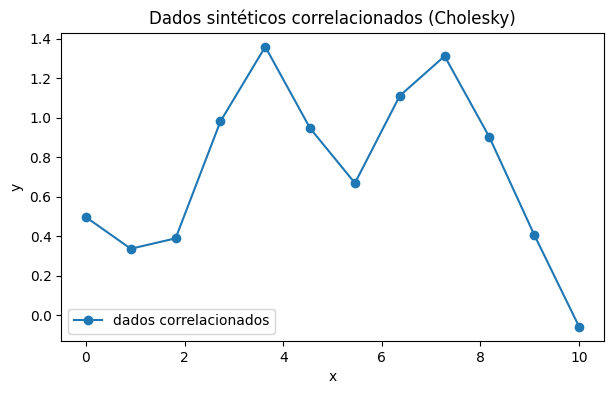

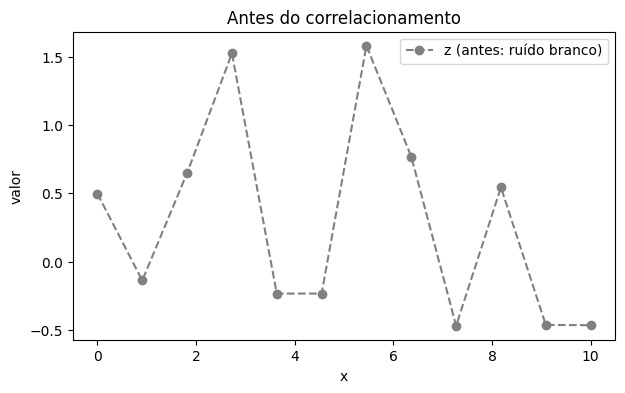

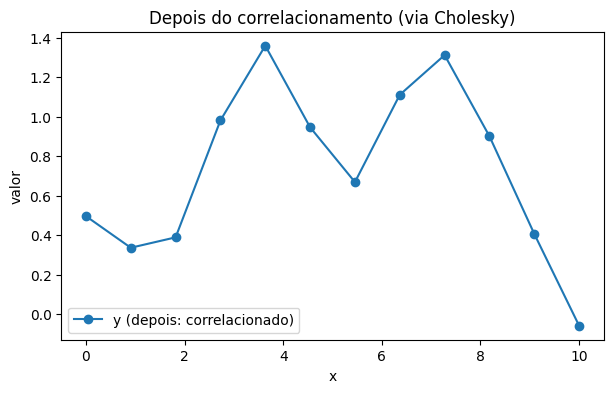

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Pontos de entrada
# -----------------------------
np.random.seed(42)

n = 12
x = np.linspace(0, 10, n)

# -----------------------------
# 2) Kernel verdadeiro
# -----------------------------
def rbf_kernel(x1, x2, sigma_f=1.0, ell=1.5):
    x1 = x1[:, None]
    x2 = x2[None, :]
    return sigma_f**2 * np.exp(-0.5 * (x1 - x2)**2 / ell**2)

K = rbf_kernel(x, x)

# -----------------------------
# 3) Decomposição de Cholesky
# -----------------------------
L = np.linalg.cholesky(K + 1e-10 * np.eye(n))  # estabilidade numérica

# -----------------------------
# 4) Amostra gaussiana correlacionada
# -----------------------------
z = np.random.randn(n)
y = L @ z   # <-- aqui nasce a correlação

# -----------------------------
# 5) Visualização
# -----------------------------
plt.figure(figsize=(7,4))
plt.plot(x, y, 'o-', label="dados correlacionados")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dados sintéticos correlacionados (Cholesky)")
plt.legend()
plt.show()

# -----------------------------
# Covariâncias
# -----------------------------
plt.figure(figsize=(7,4))
plt.plot(x, z, 'o--', color='gray', label="z (antes: ruído branco)")
plt.xlabel("x")
plt.ylabel("valor")
plt.title("Antes do correlacionamento")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(x, y, 'o-', label="y (depois: correlacionado)")
plt.xlabel("x")
plt.ylabel("valor")
plt.title("Depois do correlacionamento (via Cholesky)")
plt.legend()
plt.show()

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

# -----------------------------
# 1) Kernel do GP
# -----------------------------
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(
    length_scale=1.0,
    length_scale_bounds=(1e-2, 1e2)
)

# -----------------------------
# 2) Gaussian Process
# -----------------------------
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,          # sem ruído
    optimizer="fmin_l_bfgs_b",
    normalize_y=False
)

# -----------------------------
# 3) Fit
# -----------------------------
gp.fit(x[:, None], y)

print("Kernel aprendido:")
print(gp.kernel_)

Kernel aprendido:
0.796**2 * RBF(length_scale=1.52)


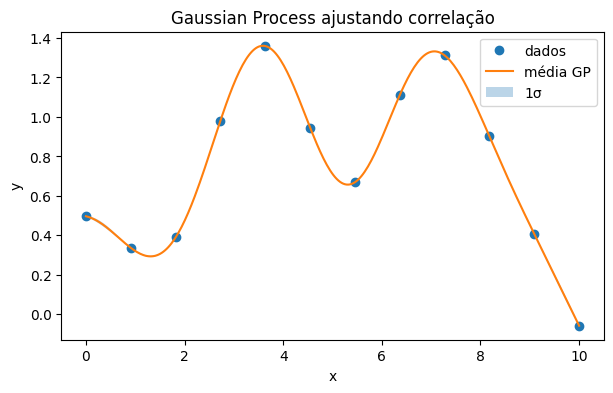

In [3]:
# Grid fino para visualização
x_star = np.linspace(0, 10, 300)
y_mean, y_std = gp.predict(x_star[:, None], return_std=True)

# Plot
plt.figure(figsize=(7,4))
plt.plot(x, y, 'o', label="dados")
plt.plot(x_star, y_mean, label="média GP")
plt.fill_between(
    x_star,
    y_mean - y_std,
    y_mean + y_std,
    alpha=0.3,
    label="1σ"
)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Gaussian Process ajustando correlação")
plt.show()